# Lecture 10: Graph Mining
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Build and visualise graph structures with NetworkX
2. Compute degree, betweenness, and PageRank centrality
3. Detect communities using the Louvain algorithm
4. Apply graph analysis to a transaction network fraud scenario

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
print(f'NetworkX version: {nx.__version__}')
print('Ready.')

NetworkX version: 3.6.1
Ready.


## 10.1 Building a Graph

In [2]:
# Create a directed weighted transaction network
G = nx.DiGraph()

# Add accounts as nodes
accounts = ['ACC_001','ACC_002','ACC_003','ACC_004','ACC_005',
            'ACC_006','ACC_007','ACC_008','ACC_009','ACC_010']
G.add_nodes_from(accounts)

# Add transactions as directed weighted edges
transactions = [
    ('ACC_001','ACC_002', 5000), ('ACC_002','ACC_003', 4800),
    ('ACC_003','ACC_001', 4600), ('ACC_001','ACC_004', 2000),  # ring: 001->002->003->001
    ('ACC_005','ACC_006',15000), ('ACC_006','ACC_007',14500),
    ('ACC_007','ACC_005',14000), ('ACC_005','ACC_008', 1000),  # ring: 005->006->007->005
    ('ACC_009','ACC_001',  500), ('ACC_009','ACC_005',  800),
    ('ACC_010','ACC_002',  300), ('ACC_010','ACC_006',  400),
    ('ACC_004','ACC_009',  200), ('ACC_008','ACC_010',  150),
]
for src, tgt, amt in transactions:
    G.add_edge(src, tgt, weight=amt)

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')
print(f'\nIn-degree (top 3):')
for node, deg in sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:3]:
    print(f'  {node}: {deg}')

Nodes: 10
Edges: 14

In-degree (top 3):
  ACC_001: 2
  ACC_002: 2
  ACC_005: 2


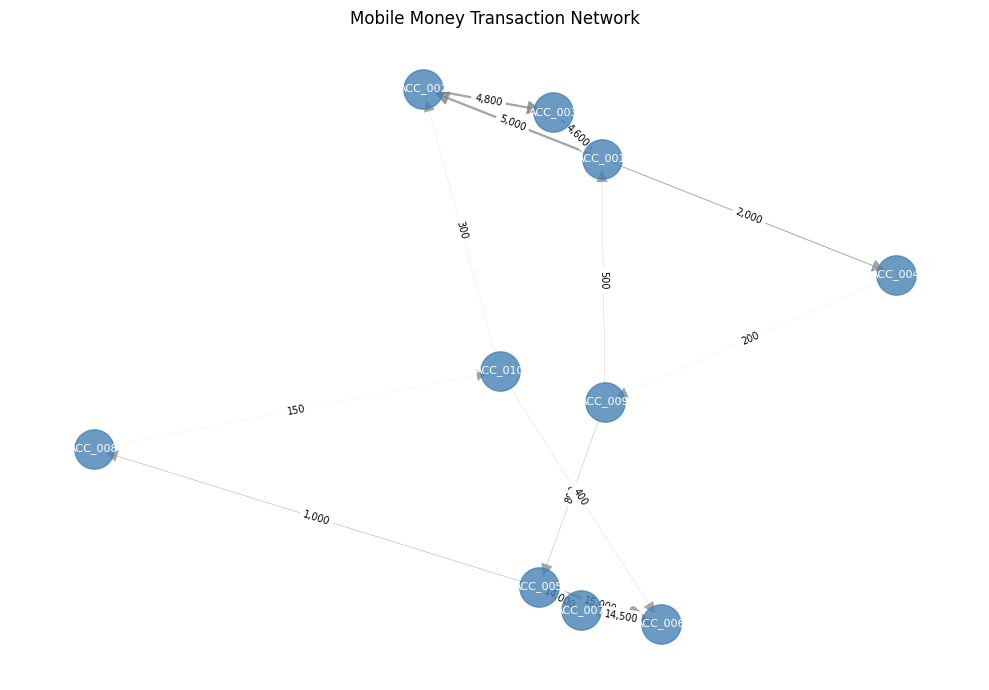

In [3]:
# Visualise the network
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42, k=2)
weights = [G[u][v]['weight']/3000 for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='steelblue', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
nx.draw_networkx_edges(G, pos, width=weights, arrows=True,
                        edge_color='gray', arrowsize=20, alpha=0.7)
plabels = {(u,v): f'{d["weight"]:,}' for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=plabels, font_size=7)
plt.title('Mobile Money Transaction Network')
plt.axis('off')
plt.tight_layout()
plt.show()

## 10.2 Centrality Measures

In [4]:
# Degree centrality
dc = nx.degree_centrality(G)
print('Degree Centrality (top 5):')
for n, s in sorted(dc.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {n}: {s:.4f}')

Degree Centrality (top 5):
  ACC_001: 0.4444
  ACC_005: 0.4444
  ACC_002: 0.3333
  ACC_006: 0.3333
  ACC_009: 0.3333


In [5]:
# Betweenness centrality
bc = nx.betweenness_centrality(G)
print('Betweenness Centrality (top 5):')
for n, s in sorted(bc.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {n}: {s:.4f}')
print('\nHigh betweenness = bridge node connecting different parts of network')

Betweenness Centrality (top 5):
  ACC_005: 0.5000
  ACC_001: 0.4167
  ACC_002: 0.3194
  ACC_003: 0.3194
  ACC_004: 0.3194

High betweenness = bridge node connecting different parts of network


In [6]:
# PageRank
pr = nx.pagerank(G, alpha=0.85, weight='weight')
print('PageRank Scores (all nodes, sorted):')
for n, s in sorted(pr.items(), key=lambda x: x[1], reverse=True):
    print(f'  {n}: {s:.6f}')
print('\nHigh PageRank = receives value from other important nodes')

PageRank Scores (all nodes, sorted):
  ACC_005: 0.184467
  ACC_006: 0.179521
  ACC_007: 0.167591
  ACC_001: 0.115734
  ACC_003: 0.098649
  ACC_002: 0.098411
  ACC_009: 0.051641
  ACC_004: 0.043107
  ACC_010: 0.036080
  ACC_008: 0.024800

High PageRank = receives value from other important nodes


In [7]:
# Centrality summary table
cent_df = pd.DataFrame({
    'Degree': dc, 'Betweenness': bc, 'PageRank': pr
}).round(4)
cent_df['in_degree'] = dict(G.in_degree())
cent_df['out_degree'] = dict(G.out_degree())
cent_df.sort_values('PageRank', ascending=False)

,Degree,Betweenness,PageRank,in_degree,out_degree
ACC_005,0.4444,0.5000,0.1845,2,2
ACC_006,0.3333,0.1528,0.1795,2,1
ACC_007,0.2222,0.1528,0.1676,1,1
ACC_001,0.4444,0.4167,0.1157,2,2
ACC_003,0.2222,0.3194,0.0986,1,1
ACC_002,0.3333,0.3194,0.0984,2,1
ACC_009,0.3333,0.3194,0.0516,1,2
ACC_004,0.2222,0.3194,0.0431,1,1
ACC_010,0.3333,0.3194,0.0361,1,2
ACC_008,0.2222,0.3194,0.0248,1,1


## 10.3 Cycle Detection — Finding Suspicious Rings

In [8]:
# Find all simple cycles (closed loops of transactions)
cycles = list(nx.simple_cycles(G))
print(f'Number of cycles detected: {len(cycles)}')
for c in cycles:
    total_value = sum(G[c[i]][c[(i+1)%len(c)]]['weight'] for i in range(len(c)))
    print(f'  Cycle: {" -> ".join(c)} -> {c[0]} | Total Value: KES {total_value:,}')

Number of cycles detected: 5
  Cycle: ACC_005 -> ACC_006 -> ACC_007 -> ACC_005 | Total Value: KES 43,500
  Cycle: ACC_005 -> ACC_008 -> ACC_010 -> ACC_002 -> ACC_003 -> ACC_001 -> ACC_004 -> ACC_009 -> ACC_005 | Total Value: KES 13,850
  Cycle: ACC_005 -> ACC_008 -> ACC_010 -> ACC_006 -> ACC_007 -> ACC_005 | Total Value: KES 30,050
  Cycle: ACC_009 -> ACC_001 -> ACC_004 -> ACC_009 | Total Value: KES 2,700
  Cycle: ACC_001 -> ACC_002 -> ACC_003 -> ACC_001 | Total Value: KES 14,400


## 10.4 Community Detection

In [9]:
# Convert to undirected for community detection
G_un = G.to_undirected()

try:
    from networkx.algorithms import community
    communities = community.louvain_communities(G_un, seed=42)
    print('Communities detected by Louvain algorithm:')
    for i, comm in enumerate(communities):
        print(f'  Community {i+1}: {sorted(comm)}')
except (ImportError, AttributeError):
    # Fallback: Girvan-Newman
    from networkx.algorithms.community import girvan_newman
    comp = girvan_newman(G_un)
    communities = next(comp)
    print('Communities detected by Girvan-Newman:')
    for i, comm in enumerate(communities):
        print(f'  Community {i+1}: {sorted(comm)}')

Communities detected by Louvain algorithm:
  Community 1: ['ACC_001', 'ACC_002', 'ACC_003', 'ACC_004', 'ACC_009', 'ACC_010']
  Community 2: ['ACC_005', 'ACC_006', 'ACC_007', 'ACC_008']


## 10.5 Fraud Indicators Summary

In [10]:
print('=== FRAUD ANALYSIS SUMMARY ===')
print(f'\n1. RING STRUCTURES: {len(cycles)} circular transaction pattern(s) detected')
for c in cycles:
    total = sum(G[c[i]][c[(i+1)%len(c)]]['weight'] for i in range(len(c)))
    print(f'   {" -> ".join(c)} -> {c[0]}: KES {total:,}')

high_bc = [(n,s) for n,s in bc.items() if s > 0.1]
print(f'\n2. BRIDGE NODES (high betweenness): {[n for n,s in high_bc]}')
print('   These accounts connect otherwise separate transaction clusters.')

high_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:3]
print(f'\n3. HIGH PAGERANK ACCOUNTS: {[n for n,s in high_pr]}')
print('   These accounts accumulate the most influence from incoming transactions.')

=== FRAUD ANALYSIS SUMMARY ===

1. RING STRUCTURES: 5 circular transaction pattern(s) detected
   ACC_005 -> ACC_006 -> ACC_007 -> ACC_005: KES 43,500
   ACC_005 -> ACC_008 -> ACC_010 -> ACC_002 -> ACC_003 -> ACC_001 -> ACC_004 -> ACC_009 -> ACC_005: KES 13,850
   ACC_005 -> ACC_008 -> ACC_010 -> ACC_006 -> ACC_007 -> ACC_005: KES 30,050
   ACC_009 -> ACC_001 -> ACC_004 -> ACC_009: KES 2,700
   ACC_001 -> ACC_002 -> ACC_003 -> ACC_001: KES 14,400

2. BRIDGE NODES (high betweenness): ['ACC_001', 'ACC_002', 'ACC_003', 'ACC_004', 'ACC_005', 'ACC_006', 'ACC_007', 'ACC_008', 'ACC_009', 'ACC_010']
   These accounts connect otherwise separate transaction clusters.

3. HIGH PAGERANK ACCOUNTS: ['ACC_005', 'ACC_006', 'ACC_007']
   These accounts accumulate the most influence from incoming transactions.


### Exercise

Using the transaction network G:

1. Add 3 new accounts (ACC_011, ACC_012, ACC_013) and create a new ring transaction pattern between them with values around KES 8,000 each.
2. Re-run the cycle detection. Does the new ring appear?
3. Re-compute betweenness centrality. Which accounts have increased betweenness after adding the new transactions?
4. Create a visualisation that colour-codes nodes by their community membership.

New ring detected: True
  Cycle: ACC_011 -> ACC_012 -> ACC_013 -> ACC_011 | Total Value: KES 24,000
  Cycle: ACC_005 -> ACC_006 -> ACC_007 -> ACC_005 | Total Value: KES 43,500
  Cycle: ACC_005 -> ACC_008 -> ACC_010 -> ACC_002 -> ACC_003 -> ACC_001 -> ACC_004 -> ACC_009 -> ACC_005 | Total Value: KES 13,850
  Cycle: ACC_005 -> ACC_008 -> ACC_010 -> ACC_006 -> ACC_007 -> ACC_005 | Total Value: KES 30,050
  Cycle: ACC_009 -> ACC_001 -> ACC_004 -> ACC_009 | Total Value: KES 2,700
  Cycle: ACC_001 -> ACC_002 -> ACC_003 -> ACC_001 | Total Value: KES 14,400

=== Betweenness change after adding the ring ===
         before   after  change
ACC_012  0.0000  0.0076  0.0076
ACC_013  0.0000  0.0076  0.0076
ACC_011  0.0000  0.0076  0.0076
ACC_006  0.1528  0.0833 -0.0694
ACC_007  0.1528  0.0833 -0.0694
ACC_002  0.3194  0.1742 -0.1452
ACC_008  0.3194  0.1742 -0.1452
ACC_003  0.3194  0.1742 -0.1452
Accounts with increased betweenness: ['ACC_012', 'ACC_013', 'ACC_011']


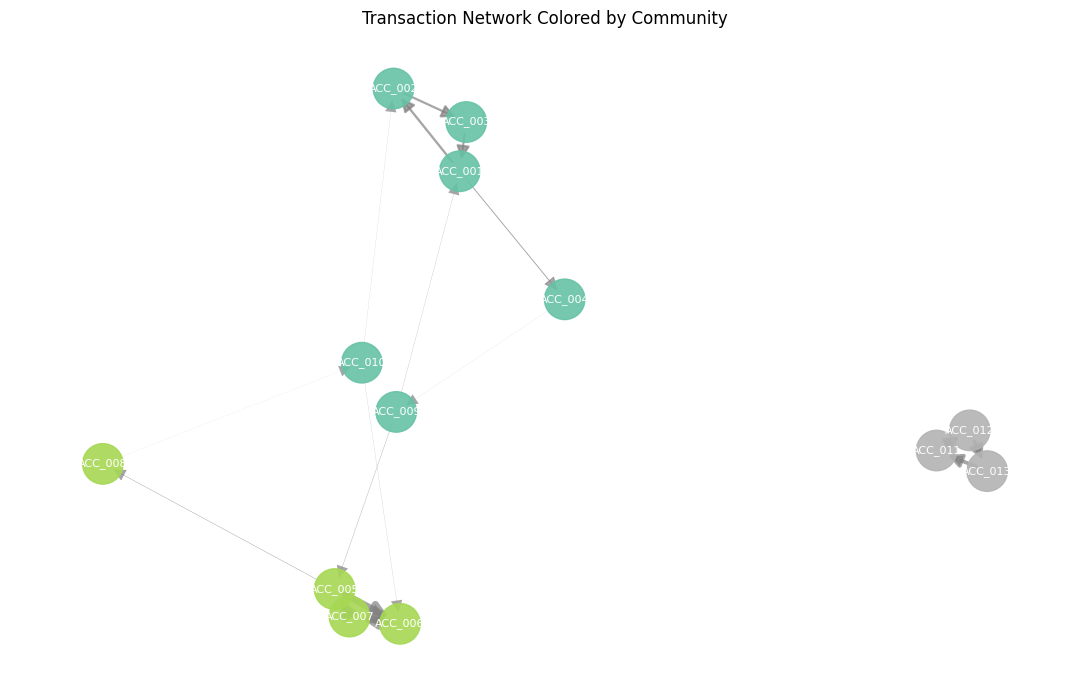

In [11]:
# Add a small ring of new accounts to the transaction graph.
new_accounts = ['ACC_011', 'ACC_012', 'ACC_013']
G.add_nodes_from(new_accounts)
new_ring = [
    ('ACC_011', 'ACC_012', 7900),
    ('ACC_012', 'ACC_013', 8100),
    ('ACC_013', 'ACC_011', 8000),
]
for src, tgt, amt in new_ring:
    G.add_edge(src, tgt, weight=amt)

# Re-run the cycle and centrality checks after the graph update.
cycles_after = list(nx.simple_cycles(G))
new_ring_present = any(len(c) == 3 and set(c) == set(new_accounts) for c in cycles_after)
print(f'New ring detected: {new_ring_present}')
for c in cycles_after:
    total_value = sum(G[c[i]][c[(i + 1) % len(c)]]['weight'] for i in range(len(c)))
    print(f'  Cycle: {" -> ".join(c)} -> {c[0]} | Total Value: KES {total_value:,}')

bc_after = nx.betweenness_centrality(G)
delta_bc = {node: bc_after.get(node, 0) - bc.get(node, 0) for node in G.nodes()}
delta_df = pd.DataFrame({
    'before': pd.Series(bc),
    'after': pd.Series(bc_after),
    'change': pd.Series(delta_bc)
}).fillna(0).sort_values('change', ascending=False)

print()
print('=== Betweenness change after adding the ring ===')
print(delta_df.head(8).round(4).to_string())
positive = delta_df[delta_df['change'] > 0]
if positive.empty:
    print('No nodes show a meaningful betweenness increase; the new ring is isolated from the original network.')
else:
    print(f'Accounts with increased betweenness: {positive.index.tolist()}')

# Re-run community detection and colour the nodes by their community labels.
G_un = G.to_undirected()
try:
    from networkx.algorithms import community
    communities = community.louvain_communities(G_un, seed=42)
except (ImportError, AttributeError):
    from networkx.algorithms.community import girvan_newman
    communities = next(girvan_newman(G_un))

community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

palette = plt.cm.Set2(np.linspace(0, 1, max(len(communities), 1)))
node_colors = [palette[community_map[node] % len(palette)] for node in G.nodes()]

plt.figure(figsize=(11, 7))
pos = nx.spring_layout(G, seed=42, k=2)
weights = [G[u][v]['weight'] / 3000 for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=850, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
nx.draw_networkx_edges(G, pos, width=weights, arrows=True, edge_color='gray', arrowsize=20, alpha=0.7)
plt.title('Transaction Network Colored by Community')
plt.axis('off')
plt.tight_layout()
plt.show()

---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*